In [1]:
# Cell 1 - Kaggle setup
!pip -q install ultralytics tqdm pyyaml

import os
import shutil
import glob
import random
from pathlib import Path

import cv2
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

KAGGLE_INPUT_ROOT = Path('/kaggle/input')
KAGGLE_WORKING_ROOT = Path('/kaggle/working')
YOLO_DATASET_ROOT = KAGGLE_WORKING_ROOT / 'yolo_dataset'
TRAIN_DEVICE = 0 if torch.cuda.is_available() else 'cpu'

plt.rcParams['figure.figsize'] = (12, 6)
print('Environment setup complete.')
print(f'Input root: {KAGGLE_INPUT_ROOT}')
print(f'Working root: {KAGGLE_WORKING_ROOT}')
print(f'Training device: {TRAIN_DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.0 MB/s eta 0:00:00
Environment setup complete.
Input root: /kaggle/input
Working root: /kaggle/working
Training device: 0
GPU: Tesla T4


In [2]:
# Cell 2 - Locate UFPR-AMR dataset in Kaggle input
required_splits = ['training', 'validation', 'testing']
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# Optional manual override if auto-discovery picks the wrong folder.
# Example: DATASET_ROOT_HINT = '/kaggle/input/datasets/anassouzaouit/dataset-ratt/UFPR-AMR Dataset'
DATASET_ROOT_HINT = None

def has_required_splits(root: Path) -> bool:
    return root.is_dir() and all((root / s).is_dir() for s in required_splits)

def discover_dataset_roots(input_root: Path, hint=None):
    candidates = []

    if hint is not None:
        hinted = Path(hint)
        if has_required_splits(hinted):
            candidates.append(hinted)

    for current_root, dirs, _ in os.walk(input_root):
        if set(required_splits).issubset(set(dirs)):
            candidates.append(Path(current_root))

    unique = []
    seen = set()
    for c in candidates:
        key = str(c.resolve())
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return sorted(unique, key=lambda p: len(str(p)))

if not KAGGLE_INPUT_ROOT.exists():
    raise EnvironmentError('/kaggle/input does not exist. Run this notebook on Kaggle.')

dataset_candidates = discover_dataset_roots(KAGGLE_INPUT_ROOT, DATASET_ROOT_HINT)
if not dataset_candidates:
    raise FileNotFoundError(
        'Could not find UFPR-AMR dataset root with training/validation/testing under /kaggle/input.'
    )

DATASET_ROOT = dataset_candidates[0]
print(f'Using dataset root: {DATASET_ROOT}')
if len(dataset_candidates) > 1:
    print('Additional candidates found:')
    for extra in dataset_candidates[1:5]:
        print(' -', extra)

split_map = {'training': 'train', 'validation': 'val', 'testing': 'test'}
for split_name in split_map.keys():
    split_dir = DATASET_ROOT / split_name
    if not split_dir.exists():
        print(f'{split_name}: split directory not found at {split_dir}')
        continue

    meter_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    direct_images = sorted([p for p in split_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
    direct_txts = sorted([p for p in split_dir.iterdir() if p.is_file() and p.suffix.lower() == '.txt'])

    recursive_images = sorted([p for p in split_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
    recursive_txts = sorted([p for p in split_dir.rglob('*.txt') if p.is_file()])

    print(
        f"{split_name}: meter folders={len(meter_dirs)}, "
        f"direct images={len(direct_images)}, direct txt={len(direct_txts)}, "
        f"recursive images={len(recursive_images)}, recursive txt={len(recursive_txts)}"
    )

Using dataset root: /kaggle/input/datasets/anassouzaouit/dataset-ratt/UFPR-AMR Dataset
training: meter folders=0, direct images=800, direct txt=800, recursive images=800, recursive txt=800
validation: meter folders=0, direct images=400, direct txt=400, recursive images=400, recursive txt=400
testing: meter folders=0, direct images=800, direct txt=800, recursive images=800, recursive txt=800


In [3]:
# Cell 3 - Conversion function: UFPR-AMR to YOLO format
def parse_counter_position(annotation_path: Path):
    import re

    keys = (
        'counter_position',
        'counter position',
        'counter-position',
        'position',
    )

    with open(annotation_path, 'r', encoding='utf-8') as f:
        lines = f.read().splitlines()

    for line in lines:
        stripped = line.strip()
        lowered = stripped.lower()

        if any(lowered.startswith(k) for k in keys):
            if ':' not in stripped:
                continue
            _, rhs = stripped.split(':', 1)
            numbers = re.findall(r'-?\d+(?:\.\d+)?', rhs)
            if len(numbers) < 4:
                continue
            try:
                x, y, w, h = map(float, numbers[:4])
            except ValueError:
                continue
            if w <= 0 or h <= 0:
                continue
            return x, y, w, h

    return None

def collect_split_samples(split_dir: Path):
    image_exts = IMAGE_EXTENSIONS if 'IMAGE_EXTENSIONS' in globals() else ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

    if not split_dir.exists():
        return [], [], []

    image_files = sorted([p for p in split_dir.rglob('*') if p.is_file() and p.suffix.lower() in image_exts])
    ann_files = sorted([p for p in split_dir.rglob('*.txt') if p.is_file()])

    images_by_stem = {}
    for img in image_files:
        images_by_stem.setdefault(img.stem, []).append(img)

    pairs = []
    unmatched_annotations = []
    seen = set()

    for ann in ann_files:
        if ann.name.lower().startswith('readme'):
            continue

        stem = ann.stem
        matched_image = None

        # Prefer image in the same directory as annotation.
        for ext in image_exts:
            candidate = ann.with_suffix(ext)
            if candidate.exists():
                matched_image = candidate
                break

        # Fallback to same-stem image anywhere in split.
        if matched_image is None:
            same_stem_images = images_by_stem.get(stem, [])
            if same_stem_images:
                matched_image = same_stem_images[0]

        if matched_image is None:
            unmatched_annotations.append(ann)
            continue

        key = (str(matched_image.resolve()), str(ann.resolve()))
        if key in seen:
            continue
        seen.add(key)
        pairs.append((matched_image, ann))

    return pairs, ann_files, unmatched_annotations

def convert_ufpr_to_yolo(dataset_root, output_root):
    dataset_root = Path(dataset_root)
    output_root = Path(output_root)

    split_in_to_out = {'training': 'train', 'validation': 'val', 'testing': 'test'}

    for out_split in split_in_to_out.values():
        (output_root / 'images' / out_split).mkdir(parents=True, exist_ok=True)
        (output_root / 'labels' / out_split).mkdir(parents=True, exist_ok=True)

    summary = {}

    for in_split, out_split in split_in_to_out.items():
        split_dir = dataset_root / in_split
        sample_pairs, ann_files, unmatched_annotations = collect_split_samples(split_dir)

        converted = 0
        skipped = 0
        warnings_count = 0

        for ann in unmatched_annotations:
            warnings_count += 1
            print(f'[WARN] No matching image for annotation: {ann}')

        pbar = tqdm(sample_pairs, desc=f'Converting {in_split}', unit='sample')
        for image_path, ann_path in pbar:
            img = cv2.imread(str(image_path))
            if img is None:
                skipped += 1
                warnings_count += 1
                print(f'[WARN] Cannot read image: {image_path}')
                continue

            img_h, img_w = img.shape[:2]
            counter = parse_counter_position(ann_path)

            if counter is None:
                skipped += 1
                warnings_count += 1
                print(f'[WARN] position/counter_position missing or invalid in {ann_path}')
                continue

            x, y, w, h = counter

            cx = (x + w / 2.0) / img_w
            cy = (y + h / 2.0) / img_h
            nw = w / img_w
            nh = h / img_h

            cx = float(np.clip(cx, 0.0, 1.0))
            cy = float(np.clip(cy, 0.0, 1.0))
            nw = float(np.clip(nw, 0.0, 1.0))
            nh = float(np.clip(nh, 0.0, 1.0))

            target_image = output_root / 'images' / out_split / image_path.name
            target_label = output_root / 'labels' / out_split / f'{image_path.stem}.txt'

            shutil.copy2(image_path, target_image)
            with open(target_label, 'w', encoding='utf-8') as f:
                f.write(f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')

            converted += 1
            pbar.set_postfix(converted=converted, skipped=skipped)

        print(f'Converted {converted}/{len(sample_pairs)} images for {in_split} split')

        summary[out_split] = {
            'source_split': in_split,
            'annotations_found': len(ann_files),
            'samples_found': len(sample_pairs),
            'converted': converted,
            'skipped': skipped,
            'warnings': warnings_count,
        }

    return summary

print('Conversion function is ready.')

Conversion function is ready.


Converting training:   0%|          | 0/800 [00:00<?, ?sample/s]

Converted 800/800 images for training split


Converting validation:   0%|          | 0/400 [00:00<?, ?sample/s]

Converted 400/400 images for validation split


Converting testing:   0%|          | 0/800 [00:00<?, ?sample/s]

Converted 800/800 images for testing split

=== Conversion Summary ===
train: annotations=800, samples=800, converted=800, skipped=0, source=training
val: annotations=400, samples=400, converted=400, skipped=0, source=validation
test: annotations=800, samples=800, converted=800, skipped=0, source=testing

=== Image/Label Count Verification ===
train: images=800, labels=800
val: images=400, labels=400
test: images=800, labels=800
Verification passed: image and label counts match in all splits.

Sample label file: /kaggle/working/yolo_dataset/labels/train/meter0001.txt
Label content: 0 0.468376 0.448077 0.185470 0.042788


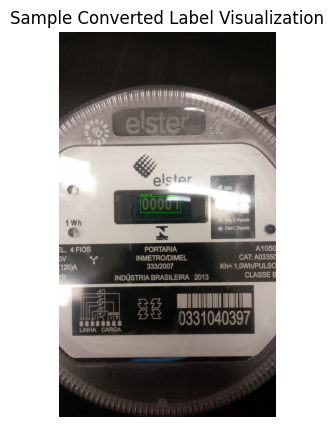

In [4]:
# Cell 4 - Run conversion and verify results
if YOLO_DATASET_ROOT.exists():
    shutil.rmtree(YOLO_DATASET_ROOT)

summary = convert_ufpr_to_yolo(DATASET_ROOT, YOLO_DATASET_ROOT)

print('\n=== Conversion Summary ===')
for split in ['train', 'val', 'test']:
    info = summary.get(split, {})
    print(
        f"{split}: annotations={info.get('annotations_found', 0)}, "
        f"samples={info.get('samples_found', 0)}, "
        f"converted={info.get('converted', 0)}, skipped={info.get('skipped', 0)}, "
        f"source={info.get('source_split', 'n/a')}"
    )

total_converted = sum(summary.get(s, {}).get('converted', 0) for s in ['train', 'val', 'test'])
if total_converted == 0:
    raise RuntimeError(
        'Conversion produced zero labels. Check annotation keys (position/counter_position) and dataset format.'
    )

# Required verification: image count must match label count for each split
print('\n=== Image/Label Count Verification ===')
for split in ['train', 'val', 'test']:
    image_files = sorted((YOLO_DATASET_ROOT / 'images' / split).glob('*.*'))
    label_files = sorted((YOLO_DATASET_ROOT / 'labels' / split).glob('*.txt'))
    print(f'{split}: images={len(image_files)}, labels={len(label_files)}')
    if len(image_files) != len(label_files):
        raise RuntimeError(f'Mismatch in split {split}: images={len(image_files)} labels={len(label_files)}')

print('Verification passed: image and label counts match in all splits.')

# Show one sample label and draw the corresponding bounding box
sample_labels = sorted((YOLO_DATASET_ROOT / 'labels' / 'train').glob('*.txt'))
if len(sample_labels) == 0:
    raise FileNotFoundError(f'No label files found in {YOLO_DATASET_ROOT / "labels" / "train"}')

sample_label = sample_labels[0]
sample_stem = sample_label.stem

candidate_images = []
for ext in ['jpg', 'jpeg', 'png', 'bmp', 'tif', 'tiff']:
    candidate = YOLO_DATASET_ROOT / 'images' / 'train' / f'{sample_stem}.{ext}'
    if candidate.exists():
        candidate_images.append(candidate)

if len(candidate_images) == 0:
    raise FileNotFoundError(f'No corresponding image found for {sample_label}')

sample_image_path = candidate_images[0]

with open(sample_label, 'r', encoding='utf-8') as f:
    label_line = f.read().strip()

print('\nSample label file:', sample_label)
print('Label content:', label_line)

parts = label_line.split()
if len(parts) != 5:
    raise ValueError(f'Invalid YOLO label format in {sample_label}: {label_line}')

_, cx, cy, nw, nh = parts
cx = float(cx)
cy = float(cy)
nw = float(nw)
nh = float(nh)

img = cv2.imread(str(sample_image_path))
if img is None:
    raise ValueError(f'Failed to read sample image: {sample_image_path}')

h, w = img.shape[:2]
bw = nw * w
bh = nh * h
x1 = int((cx * w) - bw / 2)
y1 = int((cy * h) - bh / 2)
x2 = int((cx * w) + bw / 2)
y2 = int((cy * h) + bh / 2)

vis = img.copy()
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.putText(vis, 'counter_roi', (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Sample Converted Label Visualization')
plt.axis('off')
plt.show()

In [5]:
# Cell 5 - Generate data.yaml
data_yaml = {
    'path': str(YOLO_DATASET_ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,
    'names': ['counter_roi']
}

yaml_path = YOLO_DATASET_ROOT / 'data.yaml'
yaml_path.parent.mkdir(parents=True, exist_ok=True)

with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f'data.yaml written to: {yaml_path}')
with open(yaml_path, 'r', encoding='utf-8') as f:
    print(f.read())

data.yaml written to: /kaggle/working/yolo_dataset/data.yaml
path: /kaggle/working/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
- counter_roi



In [6]:
# Cell 6 - Train YOLOv8n
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
train_results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    name='counter_roi_detector',
    patience=10,
    device=TRAIN_DEVICE,
    project=str(KAGGLE_WORKING_ROOT / 'runs' / 'detect'),
    exist_ok=True
)

print('Training complete.')
print(f'Train artifacts directory: {train_results.save_dir}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3001.8±1701.7 MB/s, size: 2949.5 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 83.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.0s/it 25.6s
                   all        400        400       0.99      0.998      0.993      0.756
Speed: 0.9ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.9934
mAP50-95: 0.7562
Precision: 0.9896
Recall: 0.9975


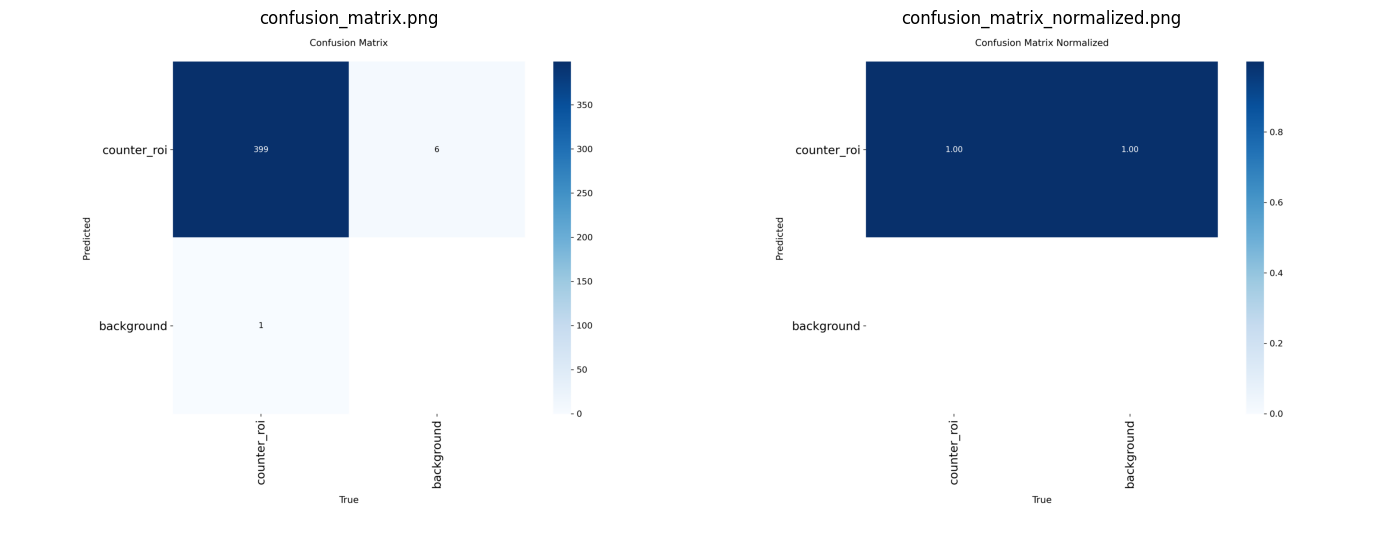

In [7]:
# Cell 7 - Validation metrics and plots
from ultralytics import YOLO

best_weights = None
if 'train_results' in globals():
    candidate = Path(train_results.save_dir) / 'weights' / 'best.pt'
    if candidate.exists():
        best_weights = candidate

if best_weights is None:
    fallback_candidates = [
        KAGGLE_WORKING_ROOT / 'runs' / 'detect' / 'counter_roi_detector' / 'weights' / 'best.pt',
        KAGGLE_WORKING_ROOT / 'models' / 'roi_model' / 'weights' / 'best.pt',
    ]
    best_weights = next((p for p in fallback_candidates if p.exists()), None)

if best_weights is None:
    raise FileNotFoundError('best.pt not found after training.')

val_model = YOLO(str(best_weights))
val_results = val_model.val(
    data=str(yaml_path),
    split='val',
    device=TRAIN_DEVICE,
    plots=True
)

box = val_results.box

def to_float(value):
    if value is None:
        return float('nan')
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value, dtype=float).flatten()
        return float(arr.mean()) if arr.size > 0 else float('nan')
    return float(value)

map50 = to_float(getattr(box, 'map50', None))
map5095 = to_float(getattr(box, 'map', None))
precision = to_float(getattr(box, 'mp', None))
recall = to_float(getattr(box, 'mr', None))

print(f'mAP50: {map50:.4f}')
print(f'mAP50-95: {map5095:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

val_save_dir = Path(getattr(val_results, 'save_dir', str(KAGGLE_WORKING_ROOT / 'runs' / 'detect' / 'val')))
plot_files = [
    val_save_dir / 'confusion_matrix.png',
    val_save_dir / 'confusion_matrix_normalized.png',
    val_save_dir / 'PR_curve.png',
]
existing_plots = [p for p in plot_files if p.exists()]

if existing_plots:
    fig, axes = plt.subplots(1, len(existing_plots), figsize=(7 * len(existing_plots), 6))
    if len(existing_plots) == 1:
        axes = [axes]
    for ax, p in zip(axes, existing_plots):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'Validation plots were not found in {val_save_dir}')

meter1344.jpg | predicted box=(527, 1803, 1239, 2049) | confidence=0.7585967183113098 | ground truth box=(526, 1809, 1225, 2017) | IoU=0.8279


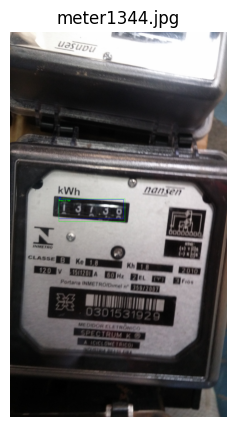

meter1974.jpg | predicted box=(858, 1499, 1786, 1703) | confidence=0.7943462133407593 | ground truth box=(850, 1513, 1789, 1703) | IoU=0.9212


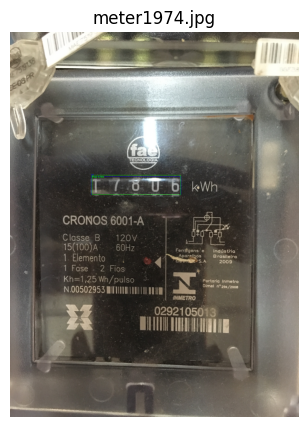

meter1298.jpg | predicted box=(652, 1762, 1183, 1887) | confidence=0.841189444065094 | ground truth box=(676, 1772, 1181, 1887) | IoU=0.8750


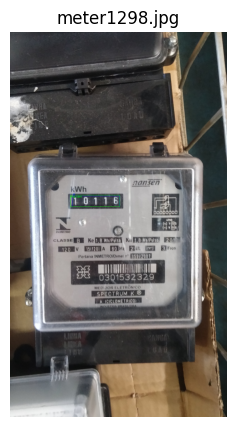

meter1834.jpg | predicted box=(1482, 2046, 1811, 2177) | confidence=0.8388422727584839 | ground truth box=(1474, 2049, 1813, 2174) | IoU=0.9273


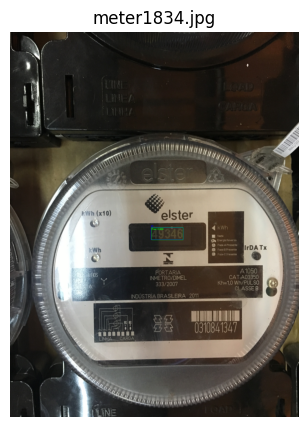

meter1457.jpg | predicted box=(1062, 985, 1959, 1169) | confidence=0.8048824667930603 | ground truth box=(1068, 979, 1946, 1156) | IoU=0.8815


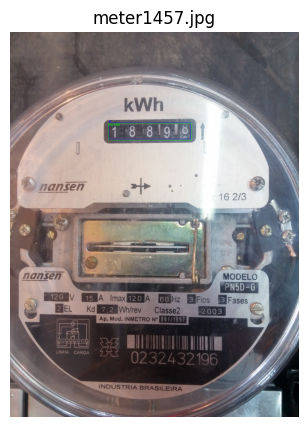

Total test images: 5 | Detections found: 5 | Average confidence: 0.8076 | Average IoU: 0.8866


In [8]:
# Cell 8 - Test inference on 5 random test images with GT comparison and IoU
from ultralytics import YOLO

def yolo_to_xyxy(cx, cy, nw, nh, img_w, img_h):
    bw = nw * img_w
    bh = nh * img_h
    x1 = int((cx * img_w) - bw / 2)
    y1 = int((cy * img_h) - bh / 2)
    x2 = int((cx * img_w) + bw / 2)
    y2 = int((cy * img_h) + bh / 2)
    return x1, y1, x2, y2

def iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union_area = area_a + area_b - inter_area
    if union_area <= 0:
        return 0.0
    return inter_area / union_area

best_weights_test = None
if 'best_weights' in globals() and Path(best_weights).exists():
    best_weights_test = Path(best_weights)
elif 'train_results' in globals():
    candidate = Path(train_results.save_dir) / 'weights' / 'best.pt'
    if candidate.exists():
        best_weights_test = candidate

if best_weights_test is None:
    fallback_candidates = [
        KAGGLE_WORKING_ROOT / 'runs' / 'detect' / 'counter_roi_detector' / 'weights' / 'best.pt',
        KAGGLE_WORKING_ROOT / 'models' / 'roi_model' / 'weights' / 'best.pt',
    ]
    best_weights_test = next((p for p in fallback_candidates if p.exists()), None)

if best_weights_test is None:
    raise FileNotFoundError('best.pt not found for test inference.')

infer_model = YOLO(str(best_weights_test))

test_images = sorted(str(p) for p in (YOLO_DATASET_ROOT / 'images' / 'test').glob('*.*'))
if len(test_images) == 0:
    raise FileNotFoundError(f'No test images found in {YOLO_DATASET_ROOT / "images" / "test"}')

num_samples = min(5, len(test_images))
sample_paths = random.sample(test_images, num_samples)

detections_found = 0
confidence_values = []
iou_values = []

for img_path in sample_paths:
    img = cv2.imread(img_path)
    if img is None:
        print(f'[WARN] Could not read test image: {img_path}')
        continue

    h, w = img.shape[:2]
    stem = Path(img_path).stem
    gt_label_path = YOLO_DATASET_ROOT / 'labels' / 'test' / f'{stem}.txt'

    gt_box = None
    if gt_label_path.exists():
        with open(gt_label_path, 'r', encoding='utf-8') as f:
            line = f.read().strip()
        parts = line.split()
        if len(parts) == 5:
            _, cx, cy, nw, nh = parts
            gt_box = yolo_to_xyxy(float(cx), float(cy), float(nw), float(nh), w, h)

    pred_result = infer_model.predict(
        source=img_path,
        imgsz=640,
        conf=0.25,
        iou=0.5,
        device=TRAIN_DEVICE,
        verbose=False
    )[0]

    pred_box = None
    pred_conf = None

    if pred_result.boxes is not None and len(pred_result.boxes) > 0:
        confs = pred_result.boxes.conf.detach().cpu().numpy()
        best_idx = int(np.argmax(confs))
        xyxy = pred_result.boxes.xyxy[best_idx].detach().cpu().numpy().tolist()
        pred_box = tuple(int(round(v)) for v in xyxy)
        pred_conf = float(confs[best_idx])

        detections_found += 1
        confidence_values.append(pred_conf)

    current_iou = float('nan')
    if pred_box is not None and gt_box is not None:
        current_iou = iou_xyxy(pred_box, gt_box)
        iou_values.append(current_iou)

    vis = img.copy()

    if gt_box is not None:
        gx1, gy1, gx2, gy2 = gt_box
        cv2.rectangle(vis, (gx1, gy1), (gx2, gy2), (255, 0, 0), 2)
        cv2.putText(vis, 'GT', (gx1, max(20, gy1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    if pred_box is not None:
        px1, py1, px2, py2 = pred_box
        cv2.rectangle(vis, (px1, py1), (px2, py2), (0, 255, 0), 2)
        cv2.putText(vis, f'Pred {pred_conf:.3f}', (px1, min(h - 10, py1 + 25)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    iou_text = f'{current_iou:.4f}' if not np.isnan(current_iou) else 'nan'
    print(f"{Path(img_path).name} | predicted box={pred_box} | confidence={pred_conf} | ground truth box={gt_box} | IoU={iou_text}")

    plt.figure(figsize=(11, 5))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(Path(img_path).name)
    plt.axis('off')
    plt.show()

avg_conf = float(np.mean(confidence_values)) if confidence_values else 0.0
avg_iou = float(np.mean(iou_values)) if iou_values else 0.0

print(
    f'Total test images: {num_samples} | Detections found: {detections_found} | '
    f'Average confidence: {avg_conf:.4f} | Average IoU: {avg_iou:.4f}'
)

In [9]:
# Cell 9 - Export best.pt for Kaggle output
source_best = None

if 'best_weights' in globals():
    candidate = Path(str(best_weights))
    if candidate.exists():
        source_best = candidate

if source_best is None and 'train_results' in globals():
    candidate = Path(train_results.save_dir) / 'weights' / 'best.pt'
    if candidate.exists():
        source_best = candidate

if source_best is None:
    fallback_candidates = [
        KAGGLE_WORKING_ROOT / 'runs' / 'detect' / 'counter_roi_detector' / 'weights' / 'best.pt',
        KAGGLE_WORKING_ROOT / 'models' / 'roi_model' / 'weights' / 'best.pt',
    ]
    source_best = next((p for p in fallback_candidates if p.exists()), None)

if source_best is None:
    raise FileNotFoundError('best.pt not found. Run training first.')

export_path = KAGGLE_WORKING_ROOT / 'best.pt'
export_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(source_best, export_path)

print(f'Exported best.pt to: {export_path}')
print(f'Source best.pt: {source_best}')
print('Kaggle note: you can download best.pt from the Notebook Output files panel.')

Exported best.pt to: /kaggle/working/best.pt
Source best.pt: /kaggle/working/runs/detect/counter_roi_detector/weights/best.pt
Kaggle note: you can download best.pt from the Notebook Output files panel.
